In [57]:
# Importing required modules
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.quantum_info import Statevector, state_fidelity
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [53]:
# Initialize Quantum and Classical Registers
N = 10  # Number of nodes in the network
q = QuantumRegister(2 * N, 'q')  # 2 qubits per node, each with 1 qubit for message and 1 for entanglement
c = ClassicalRegister(2, 'c')  # 2 classical bits to store Alice's measurement results

In [78]:
# Function to create the teleportation circuit
def create_teleportation_circuit(sender, receiver, rho_in, pw, show_circuit=False):

    # Define the indices for the sender's and receiver's qubits
    q_msg = 2 * sender
    q_alice = 2 * sender + 1
    q_bob = 2 * receiver + 1

    # Create the quantum circuit for teleportation with the appropriate registers
    teleportation_circuit = QuantumCircuit([q[q_msg], q[q_alice], q[q_bob]], c)

    # Initialize the message qubit with the state to be teleported
    teleportation_circuit.initialize(rho_in, q[q_msg], normalize=True)

    teleportation_circuit.barrier()

    # Create entanglement between Alice's and Bob's qubits
    teleportation_circuit.h(q[q_alice])
    teleportation_circuit.cx(q[q_alice], q[q_bob])

    teleportation_circuit.barrier()

    # Alice applies a quantum measurement in the Bell basis
    teleportation_circuit.cx(q[q_msg], q[q_alice])
    teleportation_circuit.h(q[q_msg])

    teleportation_circuit.measure(q[q_msg], c[0]) # Measure the message qubit
    teleportation_circuit.measure(q[q_alice], c[1]) # Measure Alice's entangled qubit

    # Bob applies correction gates based on Alice's classical results
    with teleportation_circuit.if_test((c[0], 1)):
        teleportation_circuit.z(q[q_bob])
    with teleportation_circuit.if_test((c[1], 1)):
        teleportation_circuit.x(q[q_bob])

    # Save the output density matrix for Bob's qubit
    teleportation_circuit.save_density_matrix([q[q_bob]], 'rho_out')

    # Create a depolarizing error with probability pw
    error_bell = depolarizing_error(pw, 2)

    # Create the noise model
    noise_model = NoiseModel()
    # Add the depolarizing error to the noise model for the cx gate used in the Bell state preparation
    #  in order to simulate the generation of depolarized Bell pairs
    noise_model.add_quantum_error(error_bell, ['cx'], [1, 2])

    # Visualization of the circuit (optional)
    if show_circuit:
        display(teleportation_circuit.draw('mpl'))

    # Execute the circuit on the Aer simulator with noise
    simulator = AerSimulator(method='density_matrix', noise_model=noise_model)
    compiled_circuit = transpile(teleportation_circuit, simulator)
    job = simulator.run(compiled_circuit)
    result = job.result()
    # Extract the output density matrix for Bob's qubit
    rho_out = result.data()['rho_out']

    return rho_out

In [79]:
# PARAMETERS FOR THE SIMULATION:
# Noise levels to test
pw_range = np.linspace(0, 1, 20) 
# Number of teleportation requests to simulate per noise level
n_requests_per_pw = 3 
# Arbitrary input state to teleport
a = 1/np.sqrt(2)  
b = 1/np.sqrt(2)
rho_in = Statevector([a, b])

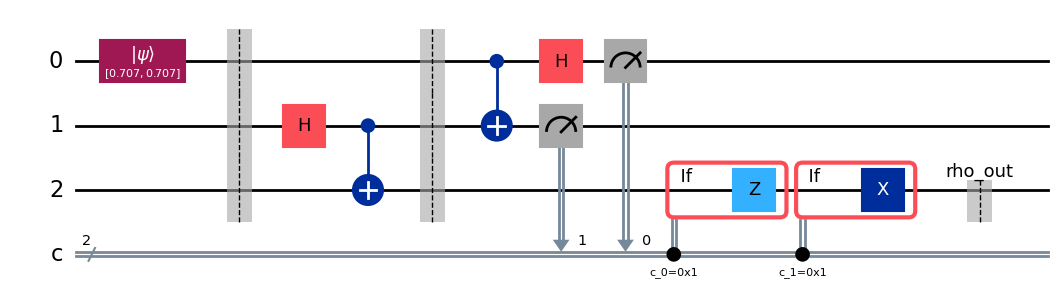

DensityMatrix([[0.5 +0.00000000e+00j, 0.45+2.01467289e-16j],
               [0.45-2.01467289e-16j, 0.5 +0.00000000e+00j]],
              dims=(2,))


In [80]:
# Run once the circuit for visualization
create_teleportation_circuit(0, 1, rho_in, 0.1, show_circuit=True)

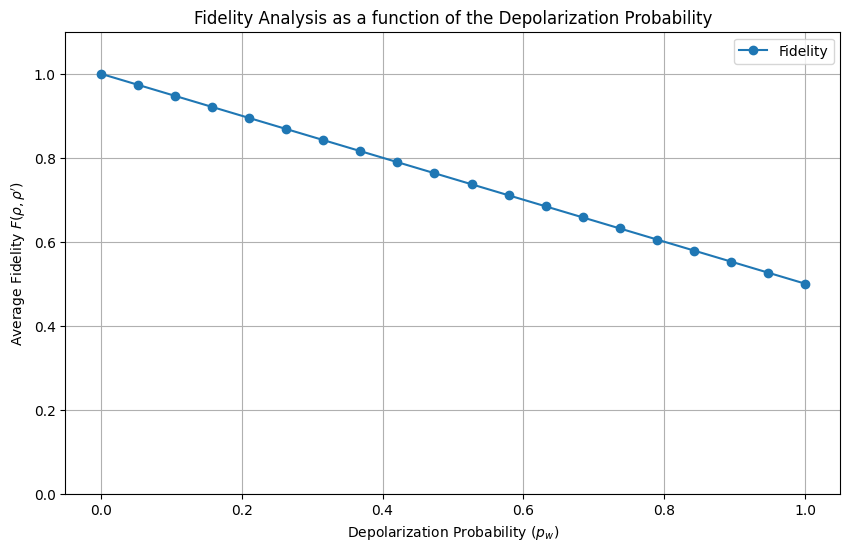

In [81]:
avg_fidelities = []

# Network Simulation Loop
for pw in pw_range:
    current_pw_fidelities = []

    for _ in range(n_requests_per_pw):
        # Randomly select sender and receiver nodes
        sender, receiver = np.random.choice(N, 2, replace=False)

        # Run the teleportation protocol and get the output state
        rho_out = create_teleportation_circuit(sender, receiver, rho_in, pw)

        # Compute the fidelity between the input and output states
        fidelity = state_fidelity(rho_in, rho_out)

        # Store the fidelity for this teleportation request
        current_pw_fidelities.append(fidelity)

    # Compute the average fidelity for this noise level
    avg_fidelity = np.mean(current_pw_fidelities)
    avg_fidelities.append(avg_fidelity)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(pw_range, avg_fidelities, 'o-', label='Fidelity')
plt.xlabel('Depolarization Probability ($p_w$)')
plt.ylabel('Average Fidelity $F(\\rho, \\rho\')$')
plt.ylim(bottom=0, top=1.1)
plt.title('Fidelity Analysis as a function of the Depolarization Probability')
plt.grid(True)
plt.legend()
plt.show()